# ETF 申购资金的指数级赚钱效应

每只 ETF 独立识别正净申购、调整份额拆分并计算收益，再按申购金额汇总到跟踪指数。将每日正份额变化视为净申购，以当日单位净值估算申购金额。当前暂以累计净值比较申购日与评价日来判断赚钱；该收益口径**需验证**，累计净值并非任意期间的复权总回报。

In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mme-matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

from etf_universe import load_etf_universe

chinese_font_candidates = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'STHeiti']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((font for font in chinese_font_candidates if font in installed_fonts), None)
if chinese_font is None:
    raise RuntimeError('未找到可用中文字体，请安装 PingFang SC、Heiti SC 或 Hiragino Sans GB 后重试。')

plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用中文字体：{chinese_font}')

使用中文字体：PingFang SC


In [2]:
shares_path = Path('data/etf_shares.parquet')
nav_path = Path('data/etf_nav.parquet')
splits_path = Path('data/etf_splits.parquet')
universe_path = Path('config/etf_universe.csv')
requested_as_of_date = None  # Example: '2026-06-30'

if not shares_path.exists():
    raise FileNotFoundError('未找到 data/etf_shares.parquet，请先运行 download_etf_shares.py。')
if not nav_path.exists():
    raise FileNotFoundError('未找到 data/etf_nav.parquet，请先运行 download_etf_nav.py。')
if not splits_path.exists():
    raise FileNotFoundError('未找到 data/etf_splits.parquet，请先运行 download_etf_nav.py。')
if not universe_path.exists():
    raise FileNotFoundError('未找到 config/etf_universe.csv。')

In [3]:
SHARE_COLUMNS = {'date', 'fund_code', 'fund_name', 'total_shares'}
NAV_COLUMNS = {'trade_date', 'fund_code', 'unit_nav', 'cumulative_nav', 'daily_return_pct'}
SPLIT_COLUMNS = {'fund_code', 'split_date', 'split_type', 'split_ratio'}
universe = load_etf_universe(universe_path)
expected_fund_codes = set(universe['fund_code'])
fund_name_map = universe.set_index('fund_code')['fund_name']
index_reference = universe[['index_code', 'index_name', 'index_order']].drop_duplicates().sort_values('index_order')

shares = pd.read_parquet(shares_path)
missing_columns = SHARE_COLUMNS - set(shares.columns)
if missing_columns:
    raise ValueError(f'份额数据缺少字段：{", ".join(sorted(missing_columns))}')
shares = shares.loc[:, sorted(SHARE_COLUMNS)].copy()
shares['fund_code'] = shares['fund_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(6)
shares['date'] = pd.to_datetime(shares['date'], errors='raise').dt.date
shares['total_shares'] = pd.to_numeric(shares['total_shares'], errors='raise')
if shares.duplicated(['date', 'fund_code']).any() or (shares['total_shares'] <= 0).any():
    raise ValueError('份额数据包含重复记录或非正份额。')
missing_share_funds = expected_fund_codes - set(shares['fund_code'])
if missing_share_funds:
    names = universe.loc[universe['fund_code'].isin(missing_share_funds), 'fund_name']
    raise ValueError(f'份额数据缺少映射 ETF：{"、".join(names)}')
shares = shares.loc[shares['fund_code'].isin(expected_fund_codes)].copy()

navs = pd.read_parquet(nav_path)
missing_columns = NAV_COLUMNS - set(navs.columns)
if missing_columns:
    raise ValueError(f'净值数据缺少字段：{", ".join(sorted(missing_columns))}')
navs = navs.loc[:, list(NAV_COLUMNS)].rename(columns={'trade_date': 'date'}).copy()
navs['fund_code'] = navs['fund_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(6)
navs['date'] = pd.to_datetime(navs['date'], errors='raise').dt.date
navs[['unit_nav', 'cumulative_nav', 'daily_return_pct']] = navs[['unit_nav', 'cumulative_nav', 'daily_return_pct']].apply(pd.to_numeric, errors='raise')
if navs.duplicated(['date', 'fund_code']).any() or (navs[['unit_nav', 'cumulative_nav']] <= 0).any().any():
    raise ValueError('净值数据包含重复记录或非正净值。')

splits = pd.read_parquet(splits_path)
missing_columns = SPLIT_COLUMNS - set(splits.columns)
if missing_columns:
    raise ValueError(f'拆分数据缺少字段：{", ".join(sorted(missing_columns))}')
splits = splits.loc[:, list(SPLIT_COLUMNS)].copy()
splits['fund_code'] = splits['fund_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(6)
splits['split_date'] = pd.to_datetime(splits['split_date'], errors='raise').dt.date
splits['split_ratio'] = pd.to_numeric(splits['split_ratio'], errors='raise')
if (splits['split_ratio'] <= 0).any():
    raise ValueError('拆分折算比例必须为正。')

eligible_navs = navs.loc[navs['fund_code'].isin(expected_fund_codes)].copy()
missing_funds = expected_fund_codes - set(eligible_navs['fund_code'])
if missing_funds:
    names = universe.loc[universe['fund_code'].isin(missing_funds), 'fund_name']
    raise ValueError(f'净值数据缺少映射 ETF：{"、".join(names)}')
if requested_as_of_date is not None:
    eligible_navs = eligible_navs.loc[eligible_navs['date'] <= pd.Timestamp(requested_as_of_date).date()]
common_dates = eligible_navs.groupby('date')['fund_code'].nunique()
common_dates = common_dates.index[common_dates == len(expected_fund_codes)]
if common_dates.empty:
    raise ValueError('没有覆盖全部 ETF 的共同评价日。')
as_of_date = max(common_dates)

shares = shares.loc[shares['date'] <= as_of_date].sort_values(['fund_code', 'date']).copy()
share_bounds = shares.groupby('fund_code', as_index=False).agg(first_date=('date', 'min'), last_date=('date', 'max'))
relevant_splits = splits.merge(share_bounds, on='fund_code', how='inner')
relevant_splits = relevant_splits.loc[
    (relevant_splits['split_date'] >= relevant_splits['first_date'])
    & (relevant_splits['split_date'] <= relevant_splits['last_date'])
].copy()
share_keys = pd.MultiIndex.from_frame(shares[['fund_code', 'date']])
split_keys = pd.MultiIndex.from_frame(relevant_splits[['fund_code', 'split_date']])
unmatched_splits = relevant_splits.loc[~split_keys.isin(share_keys)]
if not unmatched_splits.empty:
    unmatched = unmatched_splits[['fund_code', 'split_date']].astype(str).agg('/'.join, axis=1)
    raise ValueError(f'拆分日期无法匹配份额记录：{", ".join(unmatched)}')
combined_splits = relevant_splits.groupby(['fund_code', 'split_date'], as_index=False).agg(
    split_type=('split_type', lambda values: '、'.join(sorted(set(values)))),
    split_ratio=('split_ratio', 'prod'),
)
shares = shares.merge(
    combined_splits, left_on=['fund_code', 'date'], right_on=['fund_code', 'split_date'],
    how='left', validate='one_to_one',
)
shares['previous_total_shares'] = shares.groupby('fund_code')['total_shares'].shift()
split_mask = shares['split_date'].notna()
if shares.loc[split_mask, 'previous_total_shares'].isna().any():
    raise ValueError('拆分日期缺少前一条份额记录，无法自动调整。')
shares['unadjusted_share_change'] = shares['total_shares'] - shares['previous_total_shares']
effective_split_ratio = shares['split_ratio'].fillna(1.0)
shares['net_subscription_shares'] = shares['total_shares'] - shares['previous_total_shares'] * effective_split_ratio
split_adjustments = shares.loc[split_mask, [
    'fund_code', 'split_date', 'split_type', 'split_ratio', 'previous_total_shares',
    'total_shares', 'unadjusted_share_change', 'net_subscription_shares',
]].copy()
if split_adjustments.empty:
    print('分析区间内未发现需要调整的拆分记录。')
else:
    split_adjustments['display_name'] = split_adjustments['fund_code'].map(fund_name_map)
    split_review = split_adjustments.loc[:, [
        'display_name', 'split_date', 'split_type', 'split_ratio', 'previous_total_shares',
        'total_shares', 'unadjusted_share_change', 'net_subscription_shares',
    ]].rename(columns={
        'display_name': '基金简称', 'split_date': '拆分日期', 'split_type': '拆分类型',
        'split_ratio': '折算比例', 'previous_total_shares': '拆分前份额',
        'total_shares': '拆分后份额', 'unadjusted_share_change': '未调整份额变化',
        'net_subscription_shares': '调整后净申购份额',
    })
    split_review['折算比例'] = split_review['折算比例'].map(lambda ratio: f'1:{ratio:.4f}')
    print('发现份额拆分并已自动调整，请人工复核：')
    display(split_review.style.hide(axis='index').format({
        '拆分前份额': '{:,.0f}', '拆分后份额': '{:,.0f}',
        '未调整份额变化': '{:,.0f}', '调整后净申购份额': '{:,.0f}',
    }))
batches = shares.loc[shares['net_subscription_shares'] > 0].rename(columns={'date': 'subscription_date'}).copy()
nav_timeline = navs.loc[navs['date'] <= as_of_date].sort_values(['fund_code', 'date']).copy()
nav_timeline['nav_position'] = nav_timeline.groupby('fund_code').cumcount()
entry_navs = nav_timeline.rename(columns={
    'date': 'subscription_date', 'cumulative_nav': 'entry_cumulative_nav',
    'nav_position': 'entry_nav_position',
}).loc[:, ['subscription_date', 'fund_code', 'unit_nav', 'entry_cumulative_nav', 'entry_nav_position']]
batches = batches.merge(entry_navs, on=['subscription_date', 'fund_code'], how='left', validate='one_to_one')
as_of_navs = nav_timeline.loc[nav_timeline['date'] == as_of_date, [
    'fund_code', 'cumulative_nav', 'nav_position',
]].rename(columns={
    'cumulative_nav': 'as_of_cumulative_nav', 'nav_position': 'as_of_nav_position',
})
batches = batches.merge(as_of_navs, on='fund_code', how='left', validate='many_to_one')
if batches[['unit_nav', 'entry_cumulative_nav', 'as_of_cumulative_nav', 'entry_nav_position']].isna().any().any():
    raise ValueError('部分申购批次缺少净值数据。')
batches['target_60_nav_position'] = batches['entry_nav_position'] + 60
batches['completed_60_trade_days'] = batches['target_60_nav_position'] <= batches['as_of_nav_position']
batches['return_60_nav_position'] = batches['target_60_nav_position'].where(
    batches['completed_60_trade_days'], batches['as_of_nav_position'],
)
return_60_navs = nav_timeline.rename(columns={
    'date': 'return_60_date', 'cumulative_nav': 'return_60_cumulative_nav',
    'nav_position': 'return_60_nav_position',
}).loc[:, ['fund_code', 'return_60_nav_position', 'return_60_date', 'return_60_cumulative_nav']]
batches = batches.merge(
    return_60_navs, on=['fund_code', 'return_60_nav_position'], how='left', validate='many_to_one',
)
if batches['return_60_cumulative_nav'].isna().any():
    raise ValueError('部分申购批次无法定位第 60 个交易日净值。')
batches['estimated_subscription_amount'] = batches['net_subscription_shares'] * batches['unit_nav']
batches['return_60_trade_days'] = batches['return_60_cumulative_nav'] / batches['entry_cumulative_nav'] - 1
batches['return_to_date'] = batches['as_of_cumulative_nav'] / batches['entry_cumulative_nav'] - 1
batches['profitable_60_trade_days'] = batches['return_60_trade_days'] > 0
batches['profitable_to_date'] = batches['return_to_date'] > 0
batches = batches.merge(
    universe[['fund_code', 'fund_name', 'index_code', 'index_name', 'index_order']],
    on='fund_code', how='left', validate='many_to_one',
)

batches['profitable_amount_60_trade_days'] = batches['estimated_subscription_amount'].where(
    batches['profitable_60_trade_days'], 0.0,
)
batches['profitable_amount_to_date'] = batches['estimated_subscription_amount'].where(
    batches['profitable_to_date'], 0.0,
)
batches['weighted_return_60_trade_days'] = (
    batches['estimated_subscription_amount'] * batches['return_60_trade_days']
)
batches['weighted_return_to_date'] = batches['estimated_subscription_amount'] * batches['return_to_date']
index_daily_batches = batches.groupby(
    ['index_code', 'index_name', 'index_order', 'subscription_date'], as_index=False,
).agg(
    estimated_subscription_amount=('estimated_subscription_amount', 'sum'),
    weighted_return_60_trade_days=('weighted_return_60_trade_days', 'sum'),
    weighted_return_to_date=('weighted_return_to_date', 'sum'),
    completed_60_trade_days=('completed_60_trade_days', 'all'),
)
index_daily_batches['return_60_trade_days'] = (
    index_daily_batches['weighted_return_60_trade_days']
    / index_daily_batches['estimated_subscription_amount']
)
index_daily_batches['return_to_date'] = (
    index_daily_batches['weighted_return_to_date'] / index_daily_batches['estimated_subscription_amount']
)
index_daily_batches['profitable_60_trade_days'] = index_daily_batches['return_60_trade_days'] > 0
index_daily_batches['profitable_to_date'] = index_daily_batches['return_to_date'] > 0
index_amounts = batches.groupby(['index_code', 'index_name', 'index_order'], as_index=False).agg(
    subscription_amount=('estimated_subscription_amount', 'sum'),
    profitable_amount_60_trade_days=('profitable_amount_60_trade_days', 'sum'),
    profitable_amount_to_date=('profitable_amount_to_date', 'sum'),
)
index_batch_counts = index_daily_batches.groupby(
    ['index_code', 'index_name', 'index_order'], as_index=False,
).agg(
    subscription_batches=('subscription_date', 'size'),
    completed_60_trade_day_batches=('completed_60_trade_days', 'sum'),
)
summary = index_reference.merge(
    index_amounts, on=['index_code', 'index_name', 'index_order'], how='left', validate='one_to_one',
).merge(
    index_batch_counts, on=['index_code', 'index_name', 'index_order'], how='left', validate='one_to_one',
)
amount_columns = [
    'subscription_amount', 'profitable_amount_60_trade_days', 'profitable_amount_to_date',
]
count_columns = ['subscription_batches', 'completed_60_trade_day_batches']
summary[amount_columns] = summary[amount_columns].fillna(0.0)
summary[count_columns] = summary[count_columns].fillna(0).astype(int)
summary['profitable_capital_ratio_60_trade_days'] = (
    summary['profitable_amount_60_trade_days'] / summary['subscription_amount']
).where(summary['subscription_amount'] > 0)
summary['profitable_capital_ratio_to_date'] = (
    summary['profitable_amount_to_date'] / summary['subscription_amount']
).where(summary['subscription_amount'] > 0)
total_subscription_amount = batches['estimated_subscription_amount'].sum()
total_profitable_amount_60 = batches.loc[
    batches['profitable_60_trade_days'], 'estimated_subscription_amount'
].sum()
total_profitable_amount_to_date = batches.loc[
    batches['profitable_to_date'], 'estimated_subscription_amount'
].sum()
overall = pd.DataFrame([{
    'index_code': 'ALL', 'index_name': '总体', 'index_order': 99,
    'subscription_amount': total_subscription_amount,
    'profitable_amount_60_trade_days': total_profitable_amount_60,
    'profitable_amount_to_date': total_profitable_amount_to_date,
    'subscription_batches': len(index_daily_batches),
    'completed_60_trade_day_batches': int(index_daily_batches['completed_60_trade_days'].sum()),
    'profitable_capital_ratio_60_trade_days': (
        total_profitable_amount_60 / total_subscription_amount if total_subscription_amount else float('nan')
    ),
    'profitable_capital_ratio_to_date': (
        total_profitable_amount_to_date / total_subscription_amount if total_subscription_amount else float('nan')
    ),
}])
summary = pd.concat([summary, overall], ignore_index=True)

发现份额拆分并已自动调整，请人工复核：


基金简称,拆分日期,拆分类型,折算比例,拆分前份额,拆分后份额,未调整份额变化,调整后净申购份额
广发上证50ETF,2026-04-24,份额分拆,1:1.2877,"79,200,000","101,020,800","21,820,800","-965,040"


实际评价日：2026-07-16
指数 ETF 成分复核表：


指数简称,ETF数量,ETF成分
上证50,11,华夏上证50ETF、易方达上证50ETF、华安上证50ETF、申万菱信上证50ETF、万家上证50ETF、博时上证50ETF、建信上证50ETF、工银上证50ETF、广发上证50ETF、天弘上证50ETF、东财上证50ETF
沪深300,25,富国沪深300ETF、东财沪深300ETF、万家沪深300ETF、鹏华沪深300ETF、嘉实沪深300ETF、南方沪深300ETF、华泰柏瑞沪深300ETF、易方达沪深300ETF、中金沪深300ETF、华夏沪深300ETF、工银沪深300ETF、广发沪深300ETF、兴业沪深300ETF、国寿沪深300ETF、平安沪深300ETF、博时沪深300ETF、汇添富沪深300ETF、天弘沪深300ETF、民生加银沪深300ETF、方正富邦沪深300ETF、泰康沪深300ETF、华安沪深300ETF、国联安沪深300ETF、招商沪深300ETF、永赢沪深300ETF
中证500,22,东财中证500ETF、富国中证500ETF、天弘中证500ETF、嘉实中证500ETF、景顺长城中证500ETF、博时中证500ETF、鹏华中证500ETF、南方中证500ETF、广发中证500ETF、工银中证500ETF、方正富邦中证500ETF、国寿中证500ETF、兴业中证500ETF、易方达中证500ETF、平安中证500ETF、华夏中证500ETF、华泰柏瑞中证500ETF、中银证券中证500ETF、泰康中证500ETF、国联中证500ETF、国泰中证500ETF、汇添富中证500ETF
中证1000,7,富国中证1000ETF、易方达中证1000ETF、华夏中证1000ETF、南方中证1000ETF、华泰柏瑞中证1000ETF、广发中证1000ETF、汇添富中证1000ETF
中证2000,10,南方中证2000ETF、易方达中证2000ETF、博时中证2000ETF、嘉实中证2000ETF、汇添富中证2000ETF、广发中证2000ETF、国泰中证2000ETF、华夏中证2000ETF、富国中证2000ETF、华泰柏瑞中证2000ETF
红利低波,8,富国红利低波ETF、华夏红利低波ETF、天弘红利低波ETF、华泰柏瑞红利低波ETF、泰康红利低波ETF、国泰海通红利低波ETF、易方达红利低波ETF、永赢红利低波ETF
科创50,17,华夏科创50ETF、鹏华科创50ETF、工银科创50ETF、广发科创50ETF、易方达科创50ETF、华泰柏瑞科创50ETF、南方科创50ETF、国联安科创50ETF、华安科创50ETF、中银科创50ETF、万家科创50ETF、汇添富科创50ETF、富国科创50ETF、景顺长城科创50ETF、平安科创50ETF、国泰科创50ETF、东财科创50ETF


指数简称,正净申购金额,60交易日赚钱资金金额,60交易日赚钱资金比例,至今赚钱资金金额,至今赚钱资金比例,申购批次数,已满60交易日批次数
上证50,"33,154,982,825","14,903,640,375",45.0%,"14,157,091,645",42.7%,99,51
沪深300,"78,954,534,220","47,099,539,920",59.7%,"47,901,185,620",60.7%,108,52
中证500,"95,007,392,740","44,888,750,290",47.2%,"24,306,444,230",25.6%,113,64
中证1000,"117,381,833,700","30,562,014,300",26.0%,"5,687,231,600",4.8%,90,45
中证2000,"10,117,399,550","4,586,316,700",45.3%,"810,944,750",8.0%,107,55
红利低波,"25,139,148,050","9,767,974,650",38.9%,"4,719,957,700",18.8%,125,65
科创50,"68,970,311,550","34,786,985,600",50.4%,"39,271,217,650",56.9%,105,55
总体,"428,725,602,635","186,595,221,835",43.5%,"136,854,073,195",31.9%,747,387


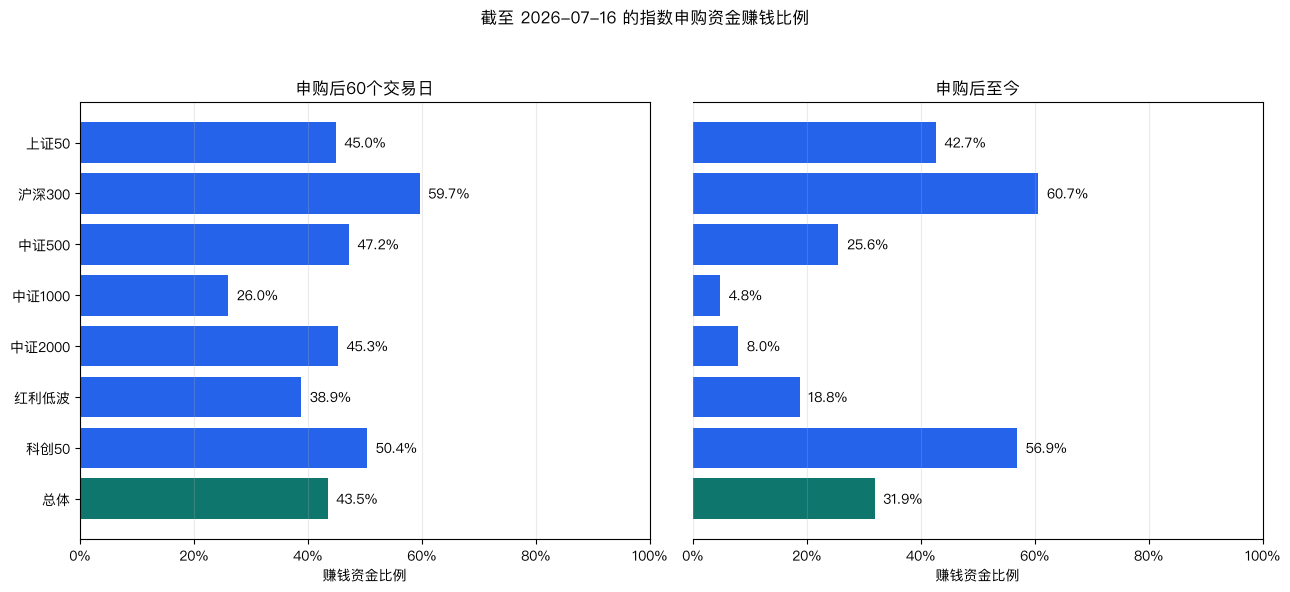

In [4]:
print(f'实际评价日：{as_of_date}')
component_review = universe.groupby(['index_name', 'index_order'], as_index=False).agg(
    etf_count=('fund_code', 'size'),
    etf_components=('fund_name', lambda values: '、'.join(values)),
).sort_values('index_order')
component_review = component_review.loc[:, ['index_name', 'etf_count', 'etf_components']].rename(columns={
    'index_name': '指数简称', 'etf_count': 'ETF数量', 'etf_components': 'ETF成分',
})
print('指数 ETF 成分复核表：')
display(component_review.style.hide(axis='index'))

display_summary = summary.loc[:, [
    'index_name', 'subscription_amount',
    'profitable_amount_60_trade_days', 'profitable_capital_ratio_60_trade_days',
    'profitable_amount_to_date', 'profitable_capital_ratio_to_date',
    'subscription_batches', 'completed_60_trade_day_batches',
]].rename(columns={
    'index_name': '指数简称', 'subscription_amount': '正净申购金额',
    'profitable_amount_60_trade_days': '60交易日赚钱资金金额',
    'profitable_capital_ratio_60_trade_days': '60交易日赚钱资金比例',
    'profitable_amount_to_date': '至今赚钱资金金额',
    'profitable_capital_ratio_to_date': '至今赚钱资金比例',
    'subscription_batches': '申购批次数',
    'completed_60_trade_day_batches': '已满60交易日批次数',
})
display(display_summary.style.hide(axis='index').format({
    '正净申购金额': '{:,.0f}', '60交易日赚钱资金金额': '{:,.0f}',
    '至今赚钱资金金额': '{:,.0f}', '60交易日赚钱资金比例': '{:.1%}',
    '至今赚钱资金比例': '{:.1%}',
}, na_rep='—'))

labels = summary['index_name']
bar_colors = ['#0F766E' if code == 'ALL' else '#2563EB' for code in summary['index_code']]
ratio_panels = [
    ('profitable_capital_ratio_60_trade_days', '申购后60个交易日'),
    ('profitable_capital_ratio_to_date', '申购后至今'),
]
figure, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for axis, (ratio_column, title) in zip(axes, ratio_panels):
    ratios = summary[ratio_column].fillna(0)
    bars = axis.barh(labels, ratios, color=bar_colors)
    axis.set_xlim(0, 1)
    axis.xaxis.set_major_formatter(PercentFormatter(1))
    axis.set_xlabel('赚钱资金比例')
    axis.set_title(title)
    axis.grid(axis='x', alpha=0.25)
    for bar, ratio, raw_ratio in zip(bars, ratios, summary[ratio_column]):
        axis.text(
            min(ratio + 0.015, 0.94), bar.get_y() + bar.get_height() / 2,
            '—' if pd.isna(raw_ratio) else f'{ratio:.1%}', va='center',
        )
axes[0].invert_yaxis()
axes[1].tick_params(axis='y', left=False, labelleft=False)
axes[1].spines['left'].set_visible(False)
figure.suptitle(f'截至 {as_of_date} 的指数申购资金赚钱比例')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

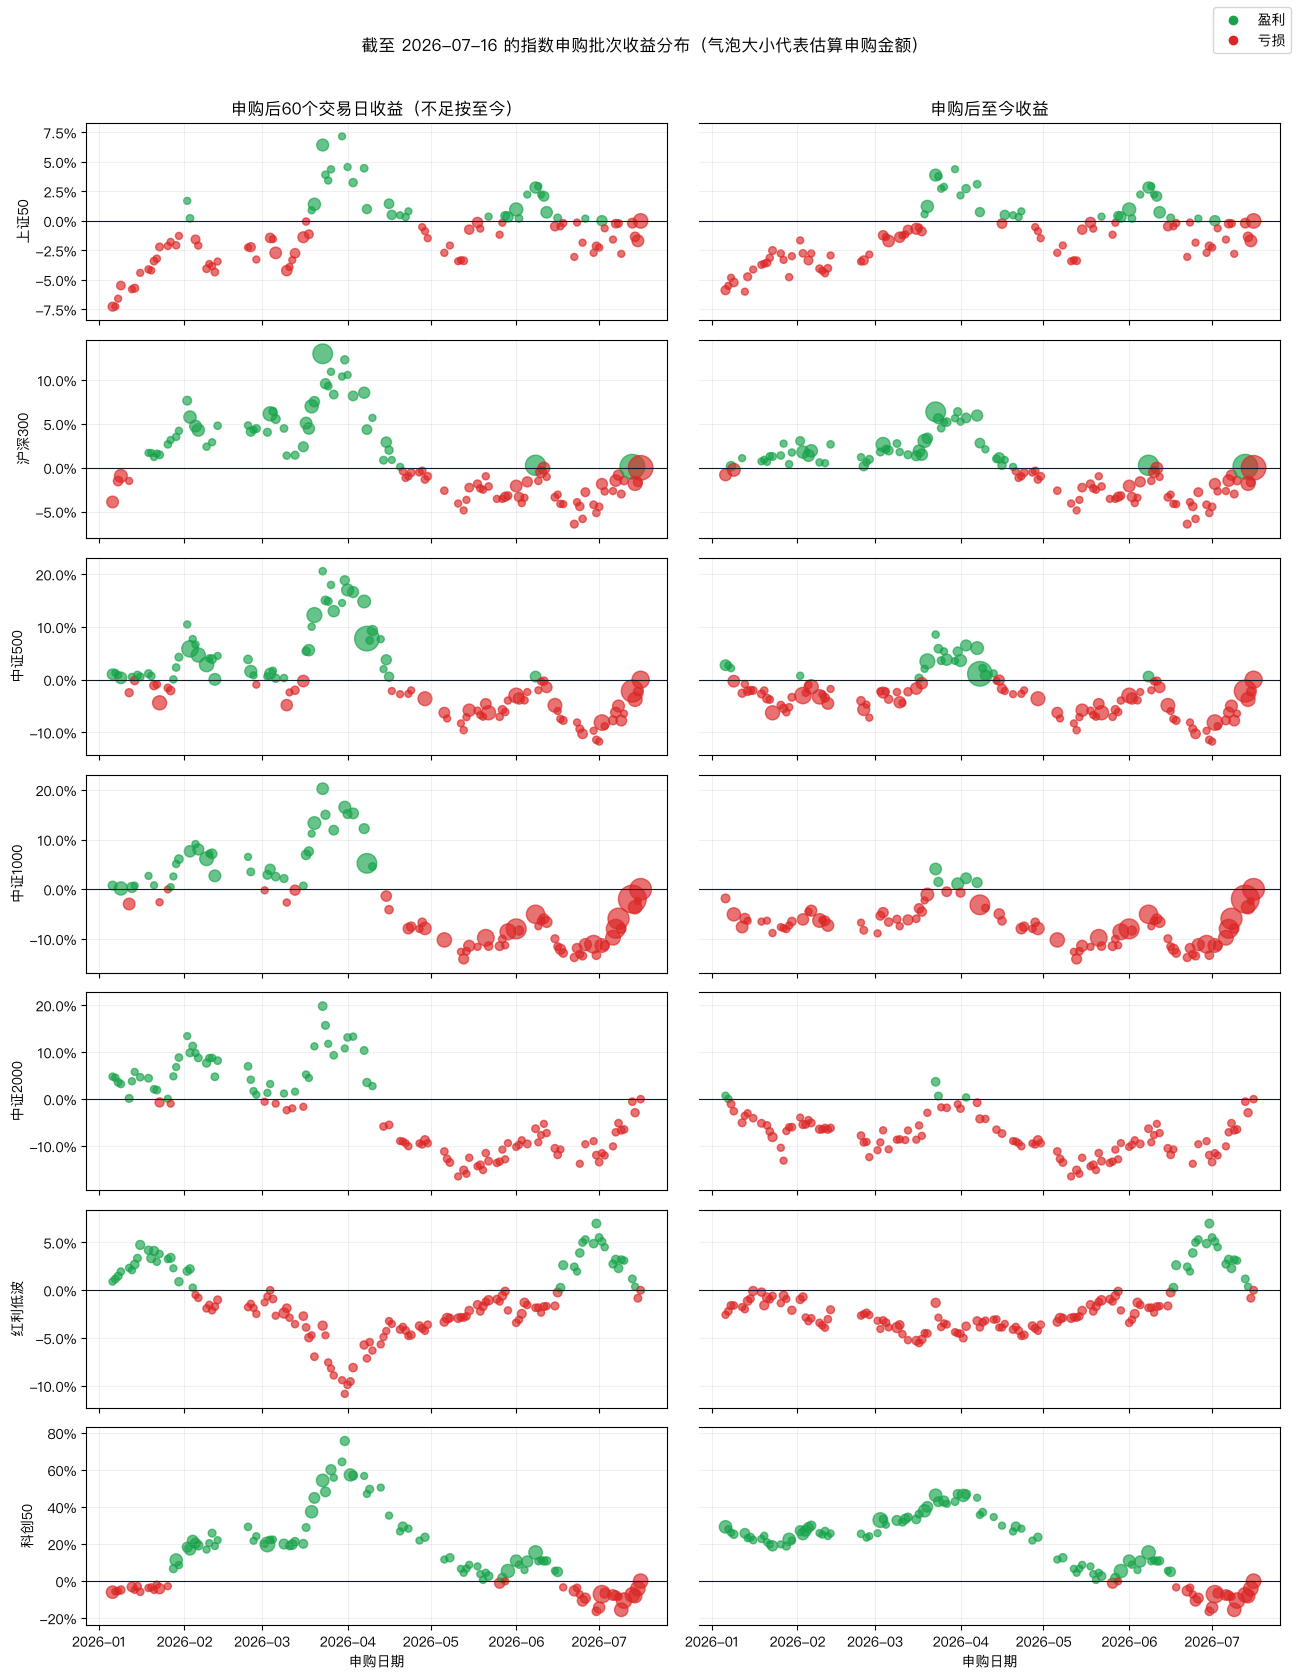

In [5]:
index_rows = index_reference.to_dict('records')
figure, axes = plt.subplots(
    len(index_rows), 2, figsize=(13, max(5, 2.4 * len(index_rows))),
    sharex=True, sharey='row', squeeze=False,
)
maximum_amount = index_daily_batches['estimated_subscription_amount'].max() if not index_daily_batches.empty else 1
return_panels = [
    ('return_60_trade_days', 'profitable_60_trade_days'),
    ('return_to_date', 'profitable_to_date'),
]

for row_index, index_row in enumerate(index_rows):
    data = index_daily_batches.loc[index_daily_batches['index_code'] == index_row['index_code']]
    bubble_sizes = 25 + 375 * data['estimated_subscription_amount'] / maximum_amount
    combined_returns = data[['return_60_trade_days', 'return_to_date']].stack()
    lower = min(combined_returns.min(), 0) if not combined_returns.empty else -0.01
    upper = max(combined_returns.max(), 0) if not combined_returns.empty else 0.01
    padding = max((upper - lower) * 0.08, 0.005)
    for column_index, (return_column, profitable_column) in enumerate(return_panels):
        axis = axes[row_index, column_index]
        if data.empty:
            axis.text(0.5, 0.5, '无正净申购批次', ha='center', va='center', transform=axis.transAxes)
        else:
            colors = data[profitable_column].map({True: '#16A34A', False: '#DC2626'})
            axis.scatter(
                data['subscription_date'], data[return_column],
                s=bubble_sizes, c=colors, alpha=0.65,
            )
        axis.axhline(0, color='#111827', linewidth=0.8)
        axis.yaxis.set_major_formatter(PercentFormatter(1))
        axis.grid(alpha=0.2)
    axes[row_index, 0].set_ylim(lower - padding, upper + padding)
    axes[row_index, 0].set_ylabel(index_row['index_name'])
    axes[row_index, 1].tick_params(axis='y', left=False, labelleft=False)
    axes[row_index, 1].spines['left'].set_visible(False)

axes[0, 0].set_title('申购后60个交易日收益（不足按至今）')
axes[0, 1].set_title('申购后至今收益')
legend_handles = [
    Line2D([], [], marker='o', linestyle='', color='#16A34A', label='盈利'),
    Line2D([], [], marker='o', linestyle='', color='#DC2626', label='亏损'),
]
figure.legend(handles=legend_handles, loc='upper right')
axes[-1, 0].set_xlabel('申购日期')
axes[-1, 1].set_xlabel('申购日期')
figure.suptitle(f'截至 {as_of_date} 的指数申购批次收益分布（气泡大小代表估算申购金额）')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()